
# 🐶 Dogs vs Cats Image Classification with a CNN (TensorFlow / Keras) 🐱

**Dataset:** [Dog and Cat Classification Dataset](https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset)

## Project Overview
This notebook builds an end-to-end binary image classification pipeline that
distinguishes photographs of **dogs** from photographs of **cats** using a
**Convolutional Neural Network (CNN) built from scratch** (no transfer
learning) in TensorFlow/Keras.

### Pipeline stages
1. **Environment setup** — imports and reproducibility configuration.
2. **Dataset inspection** — walk the Kaggle input directory with `os.walk()`
   to understand exactly what we are working with before touching any image.
3. **Data integrity check** — detect and discard corrupted / unreadable image
   files so they cannot crash training later.
4. **Train / validation / test split** — a stratified split so each subset
   has a balanced proportion of cats and dogs.
5. **Preprocessing & augmentation** — resizing to 224×224, pixel
   normalization, and on-the-fly augmentation (rotation, zoom, horizontal
   flip) applied only to the training set.
6. **Model architecture** — a CNN built from `Conv2D`, `BatchNormalization`,
   `MaxPooling2D`, `Dropout`, and `Dense` layers.
7. **Training** — Adam optimizer, binary cross-entropy loss, with
   `EarlyStopping` and `ModelCheckpoint` callbacks.
8. **Evaluation** — accuracy, precision, recall, F1-score, confusion matrix,
   and a full classification report on a held-out test set.
9. **Visualization** — sample images, training curves, and a confusion
   matrix heatmap.
10. **Custom prediction** — a reusable function to classify any new dog/cat
    image with a confidence score.

> **How to use this notebook on Kaggle:** Create a new notebook, add the
> dataset *"Dog and Cat Classification Dataset"* via *Add Data*, set the
> accelerator to **GPU** (Settings → Accelerator), and run all cells in
> order (*Run All*).



## 1. Import Libraries

We import:
- **TensorFlow / Keras** for building and training the CNN.
- **NumPy / Pandas** for numerical and tabular data handling.
- **Matplotlib / Seaborn** for visualization.
- **scikit-learn** for evaluation metrics (precision, recall, F1, confusion
  matrix) and for the stratified train/val/test split.
- **PIL (Pillow)** to validate that image files are readable (used in the
  corrupted-image check).
- **os, pathlib, random, warnings** for filesystem inspection and utility
  tasks.


In [19]:

# ===========================================================================
# 1. IMPORT LIBRARIES
# ===========================================================================
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Dropout, Dense, Flatten, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from PIL import Image, UnidentifiedImageError

warnings.filterwarnings("ignore")

# Reproducibility: fix random seeds across libraries
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]



## 2. Configuration

All tunable settings live in one place so the notebook is easy to adapt.

- `IMG_SIZE`: every image is resized to **224×224**, a common input size for
  CNNs that balances detail retention with computational cost.
- `BATCH_SIZE`: number of images processed per training step.
- `MAX_IMAGES_PER_CLASS`: optional cap to speed up experimentation. Set to
  `None` to use the **entire** dataset (recommended once you've confirmed
  the pipeline works end-to-end).
- `TRAIN_FRAC / VAL_FRAC / TEST_FRAC`: the 70/15/15 split ratios.


In [40]:

# ===========================================================================
# 2. CONFIGURATION
# ===========================================================================

# Root of the Kaggle dataset. On Kaggle, datasets attached to a notebook are
# mounted under /kaggle/input/<dataset-slug>/
# DATASET_SLUG = "dog-and-cat-classification-dataset"
INPUT_DIR = f"/kaggle/input/datasets/bhavikjikadara"  #{DATASET_SLUG}

# Working directory for outputs (models, checkpoints) — this is the ONLY
# directory that is writable on Kaggle.
WORKING_DIR = "/kaggle/working"

IMG_SIZE = (224, 224)      # (height, width) all images are resized to
IMG_CHANNELS = 3           # RGB images
BATCH_SIZE = 32
EPOCHS = 25

# Set to an integer (e.g. 2000) to subsample each class for a quick test
# run, or None to use every valid image found in the dataset.
MAX_IMAGES_PER_CLASS = None

# Train / validation / test split proportions (must sum to 1.0)
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

os.makedirs(WORKING_DIR, exist_ok=True)
print("Dataset input directory:", INPUT_DIR)
print("Writable working directory:", WORKING_DIR)


Dataset input directory: /kaggle/input/datasets/bhavikjikadara
Writable working directory: /kaggle/working



## 3. Inspect the Kaggle Dataset Folder Structure

Before loading a single image, we **walk the entire input directory tree**
with `os.walk()` and print it out. This is essential on Kaggle because:

- Dataset folder layouts vary between uploaders (e.g. `PetImages/Cat`,
  `PetImages/Dog` vs. `cats/`, `dogs/` directly).
- It lets us catch path mistakes immediately instead of after a long-running
  training job fails.
- It gives us a quick sanity check on file counts per folder.

We cap the printed output to a reasonable depth/number of files per folder
so the notebook log stays readable even for a dataset with tens of
thousands of images.


In [41]:

# ===========================================================================
# 3. INSPECT DATASET STRUCTURE (os.walk)
# ===========================================================================

def print_directory_tree(root_dir, max_files_per_dir=5):
    """
    Walk `root_dir` recursively with os.walk() and print a readable summary
    of every sub-directory: its path, the number of files it directly
    contains, and a short sample of file names.
    """
    if not os.path.exists(root_dir):
        print(f"WARNING: path does not exist yet: {root_dir}")
        return

    print(f"Walking dataset root: {root_dir}\n" + "-" * 70)
    for dirpath, dirnames, filenames in os.walk(root_dir):
        depth = dirpath.replace(root_dir, "").count(os.sep)
        indent = "    " * depth
        n_files = len(filenames)
        print(f"{indent}{os.path.basename(dirpath) or dirpath}/  "
              f"[{n_files} files, {len(dirnames)} sub-dirs]")
        # Show a small sample of filenames so we can eyeball extensions etc.
        sample = filenames[:max_files_per_dir]
        for f in sample:
            print(f"{indent}    - {f}")
        if n_files > max_files_per_dir:
            print(f"{indent}    ... ({n_files - max_files_per_dir} more files)")

print_directory_tree(INPUT_DIR)


Walking dataset root: /kaggle/input/datasets/bhavikjikadara
----------------------------------------------------------------------
bhavikjikadara/  [0 files, 1 sub-dirs]
    dog-and-cat-classification-dataset/  [0 files, 1 sub-dirs]
        PetImages/  [0 files, 2 sub-dirs]
            Dog/  [12499 files, 0 sub-dirs]
                - 7981.jpg
                - 6234.jpg
                - 1269.jpg
                - 3863.jpg
                - 6241.jpg
                ... (12494 more files)
            Cat/  [12499 files, 0 sub-dirs]
                - 7981.jpg
                - 6234.jpg
                - 1269.jpg
                - 3863.jpg
                - 6241.jpg
                ... (12494 more files)



## 4. Automatically Locate the "Cat" and "Dog" Image Folders

Rather than hard-coding a single expected path (which breaks the moment the
dataset is re-uploaded with a slightly different layout), we **search the
directory tree for folders whose name indicates the class** (`cat`, `cats`,
`dog`, `dogs` — case-insensitive). Every image file found inside a matching
folder is recorded together with its inferred label.

This approach is robust to nested structures such as
`.../PetImages/Cat/*.jpg` or a flatter `.../Cat/*.jpg`.


In [42]:

# ===========================================================================
# 4. DYNAMICALLY DISCOVER CLASS FOLDERS AND COLLECT FILE PATHS
# ===========================================================================

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

CLASS_KEYWORDS = {
    "cat":  ["cat", "cats"],
    "dog":  ["dog", "dogs"],
}

def discover_class_files(root_dir):
    """
    Walk `root_dir` and bucket every image file into 'cat' or 'dog' based on
    the name of the immediate parent folder. Returns a dict:
        {"cat": [filepaths...], "dog": [filepaths...]}
    """
    found = {"cat": [], "dog": []}

    for dirpath, dirnames, filenames in os.walk(root_dir):
        folder_name = os.path.basename(dirpath).lower()
        matched_class = None
        for cls, keywords in CLASS_KEYWORDS.items():
            if folder_name in keywords:
                matched_class = cls
                break
        if matched_class is None:
            continue

        for fname in filenames:
            if fname.lower().endswith(VALID_EXTENSIONS):
                found[matched_class].append(os.path.join(dirpath, fname))

    return found

class_files = discover_class_files(INPUT_DIR)

for cls, files in class_files.items():
    print(f"Class '{cls}': {len(files)} image files found")

assert len(class_files["cat"]) > 0 and len(class_files["dog"]) > 0, (
    "Could not locate cat/dog image folders automatically. "
    "Inspect the printed directory tree above and adjust CLASS_KEYWORDS "
    "or INPUT_DIR accordingly."
)


Class 'cat': 12499 image files found
Class 'dog': 12499 image files found



## 5. Detect and Remove Corrupted / Unreadable Images

Real-world scraped image datasets (this one included) commonly contain a
small number of **truncated, zero-byte, or otherwise corrupted files** that
will crash training if they reach `ImageDataGenerator`. We defensively
validate every file **before** building the training pipeline:

1. Confirm the file size is greater than zero bytes.
2. Open the file with **Pillow** and call `.verify()`, which checks the
   internal file structure without fully decoding pixel data.
3. Re-open and call `.convert("RGB")` to confirm the image can actually be
   decoded into pixel data (catches some corrupt files that pass
   `.verify()` but fail on full decode).

> **Note on Kaggle:** `/kaggle/input` is **read-only**, so we cannot delete
> corrupted files from disk. Instead, we simply **exclude their paths** from
> the list used to build our dataset — functionally equivalent to removal
> for the purposes of this pipeline.


In [43]:

# ===========================================================================
# 5. DETECT AND FILTER OUT CORRUPTED / UNREADABLE IMAGES
# ===========================================================================

def is_valid_image(filepath):
    """
    Return True if `filepath` can be opened and decoded as a valid image,
    False otherwise (corrupted, truncated, zero-byte, or unreadable file).
    """
    try:
        if os.path.getsize(filepath) == 0:
            return False
        # Pass 1: structural verification (fast, doesn't decode all pixels)
        with Image.open(filepath) as img:
            img.verify()
        # Pass 2: full decode to RGB to catch files that pass verify()
        # but are still broken when actually loaded for training
        with Image.open(filepath) as img:
            img.convert("RGB")
        return True
    except (UnidentifiedImageError, OSError, ValueError):
        return False

def filter_valid_images(filepaths):
    """Filter a list of filepaths, keeping only valid, readable images."""
    valid, corrupted = [], []
    for fp in filepaths:
        if is_valid_image(fp):
            valid.append(fp)
        else:
            corrupted.append(fp)
    return valid, corrupted

cleaned_class_files = {}
total_corrupted = 0

for cls, files in class_files.items():
    valid, corrupted = filter_valid_images(files)
    cleaned_class_files[cls] = valid
    total_corrupted += len(corrupted)
    print(f"Class '{cls}': {len(valid)} valid / {len(corrupted)} corrupted "
          f"(removed from the dataset)")
    if corrupted:
        print("  Examples of corrupted files skipped:", corrupted[:3])

print(f"\nTotal corrupted/unreadable images excluded: {total_corrupted}")


Class 'cat': 12499 valid / 0 corrupted (removed from the dataset)
Class 'dog': 12499 valid / 0 corrupted (removed from the dataset)

Total corrupted/unreadable images excluded: 0



## 6. Build a Labeled DataFrame and Split into Train / Validation / Test

We now:
1. Optionally subsample each class to `MAX_IMAGES_PER_CLASS` for faster
   iteration during development.
2. Combine all valid file paths into a single Pandas `DataFrame` with
   columns `filepath` and `label` (`"cat"` / `"dog"`).
3. Perform a **stratified** split: 70% train, 15% validation, 15% test,
   stratifying on `label` so all three sets preserve the same class
   balance as the full dataset. This is done in two steps:
   - First split off the test set.
   - Then split the remainder into train and validation.


In [44]:

# ===========================================================================
# 6. BUILD DATAFRAME AND CREATE TRAIN / VALIDATION / TEST SPLITS
# ===========================================================================

rows = []
for cls, files in cleaned_class_files.items():
    files_to_use = files
    if MAX_IMAGES_PER_CLASS is not None:
        files_to_use = files[:MAX_IMAGES_PER_CLASS]
    for fp in files_to_use:
        rows.append({"filepath": fp, "label": cls})

data_df = pd.DataFrame(rows)
data_df = data_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print("Total usable images:", len(data_df))
print(data_df["label"].value_counts())

# Step 1: carve off the test set
train_val_df, test_df = train_test_split(
    data_df,
    test_size=TEST_FRAC,
    stratify=data_df["label"],
    random_state=SEED,
)

# Step 2: split the remainder into train / validation
val_relative_frac = VAL_FRAC / (TRAIN_FRAC + VAL_FRAC)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_relative_frac,
    stratify=train_val_df["label"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"\nTrain set: {len(train_df)} images")
print(train_df['label'].value_counts())
print(f"\nValidation set: {len(val_df)} images")
print(val_df['label'].value_counts())
print(f"\nTest set: {len(test_df)} images")
print(test_df['label'].value_counts())


Total usable images: 24998
label
cat    12499
dog    12499
Name: count, dtype: int64

Train set: 17498 images
label
cat    8749
dog    8749
Name: count, dtype: int64

Validation set: 3750 images
label
cat    1875
dog    1875
Name: count, dtype: int64

Test set: 3750 images
label
dog    1875
cat    1875
Name: count, dtype: int64



## 7. Visualize Sample Images

A quick visual sanity check: display a grid of randomly sampled training
images with their labels. This confirms that file paths and labels are
correctly aligned before we invest time in training.


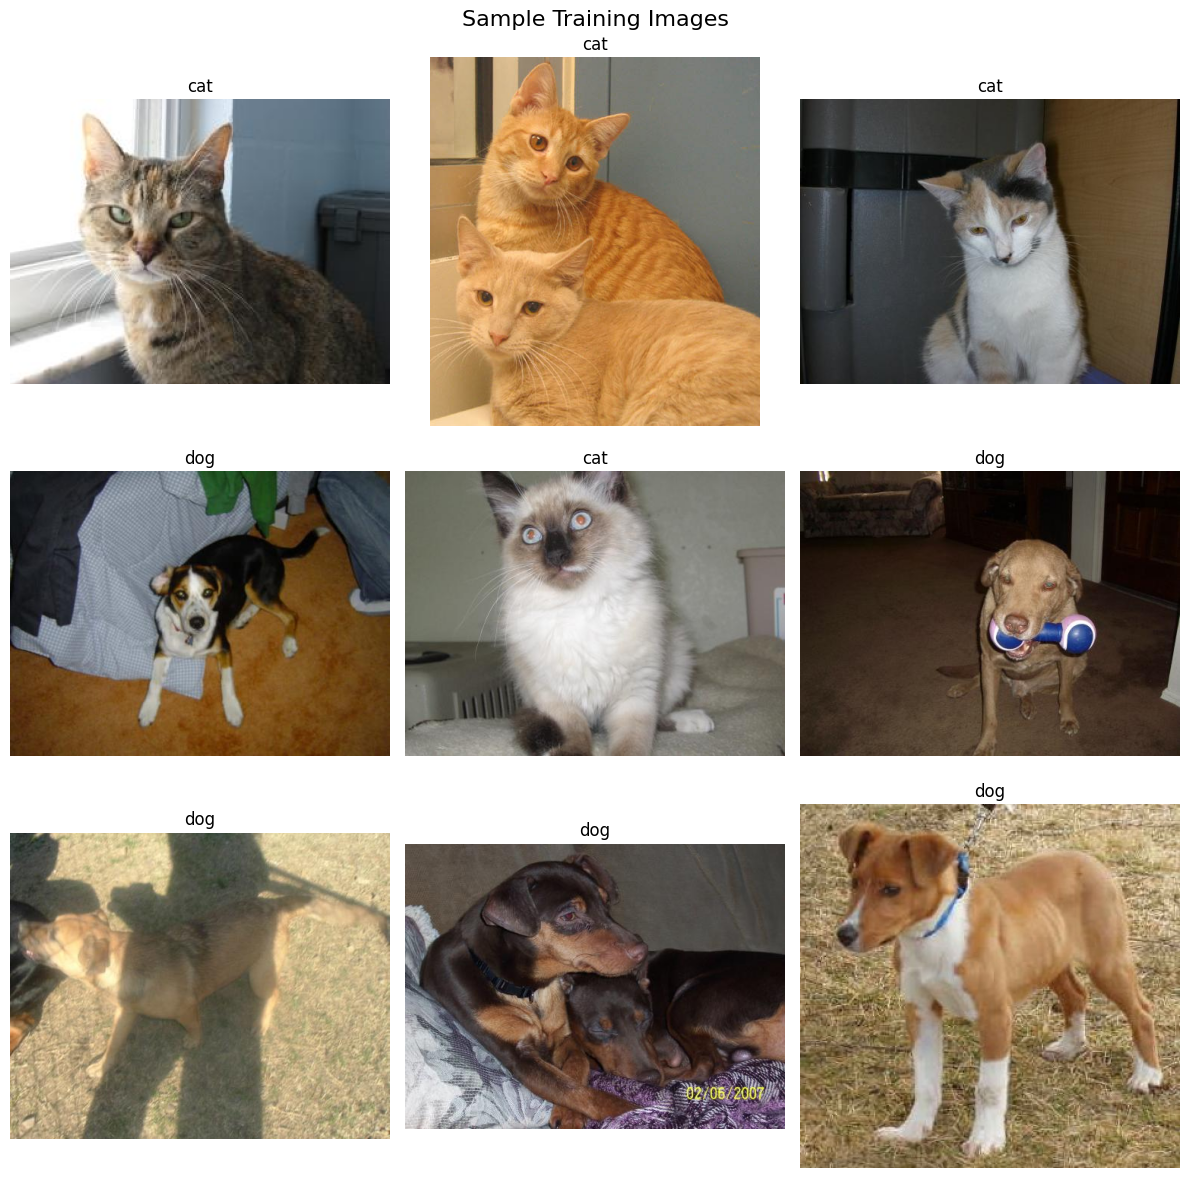

In [45]:

# ===========================================================================
# 7. DISPLAY SAMPLE IMAGES FROM THE DATASET
# ===========================================================================

def show_sample_images(df, n=9, title="Sample images"):
    sample = df.sample(n=n, random_state=SEED).reset_index(drop=True)
    cols = 3
    rows_n = int(np.ceil(n / cols))
    plt.figure(figsize=(12, 4 * rows_n))
    for i, row in sample.iterrows():
        img = mpimg.imread(row["filepath"])
        ax = plt.subplot(rows_n, cols, i + 1)
        ax.imshow(img)
        ax.set_title(row["label"], fontsize=12)
        ax.axis("off")
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

show_sample_images(train_df, n=9, title="Sample Training Images")



## 8. Image Preprocessing and Data Augmentation

We use `ImageDataGenerator.flow_from_dataframe()` so we can feed it the
exact, already-cleaned and split DataFrames from Section 6.

**Preprocessing applied to every set:**
- `rescale=1./255` — normalizes pixel values from `[0, 255]` to `[0, 1]`,
  which helps gradient-based optimization converge faster and more stably.
- All images are resized to `IMG_SIZE = (224, 224)` via `target_size`.

**Augmentation applied ONLY to the training set** (never to validation or
test, since those must reflect real, un-augmented data for an honest
evaluation):
- `rotation_range=30` — randomly rotates images up to 30°, helping the
  model become invariant to camera angle.
- `zoom_range=0.2` — randomly zooms in/out, simulating different distances
  from the subject.
- `horizontal_flip=True` — randomly mirrors images left-right (a cat facing
  left is still a cat facing right).

We use `class_mode="binary"` since this is a two-class problem, and we keep
`shuffle=False` for the test generator so that predictions line up
positionally with `test_df` for evaluation later.


In [46]:

# ===========================================================================
# 8. IMAGE PREPROCESSING + DATA AUGMENTATION PIPELINES
# ===========================================================================

# Training generator: normalization + augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
)

# Validation / test generators: normalization ONLY (no augmentation),
# so evaluation reflects real-world, unmodified images.
val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=SEED,
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)

# class_indices tells us which integer label corresponds to which class name
print("Class index mapping:", train_generator.class_indices)


Found 17498 validated image filenames belonging to 2 classes.
Found 3750 validated image filenames belonging to 2 classes.
Found 3750 validated image filenames belonging to 2 classes.
Class index mapping: {'cat': 0, 'dog': 1}



## 9. Build the CNN Architecture from Scratch

We design a classic, progressively deepening CNN:

| Block | Layers | Purpose |
|-------|--------|---------|
| 1 | `Conv2D(32)` → `BatchNormalization` → `MaxPooling2D` | Learns low-level features: edges, colors, textures |
| 2 | `Conv2D(64)` → `BatchNormalization` → `MaxPooling2D` | Learns mid-level patterns: fur texture, shapes |
| 3 | `Conv2D(128)` → `BatchNormalization` → `MaxPooling2D` | Learns higher-level parts: ears, eyes, snouts |
| 4 | `Conv2D(256)` → `BatchNormalization` → `MaxPooling2D` | Learns complex, class-discriminative features |
| Head | `Flatten` → `Dense(256)` → `Dropout(0.5)` → `Dense(1, sigmoid)` | Combines learned features into a final binary decision |

**Why each component is used:**
- **`Conv2D`** layers learn spatial filters that detect visual patterns;
  stacking them builds a hierarchy from simple edges to complex shapes.
- **`BatchNormalization`** normalizes layer activations, which stabilizes
  and speeds up training and acts as a mild regularizer.
- **`MaxPooling2D`** downsamples feature maps, reducing computation and
  providing translation invariance (small shifts in the image don't change
  the output much).
- **`Dropout(0.5)`** randomly disables 50% of neurons in the dense layer
  during training, which strongly reduces overfitting — important given how
  visually similar some cat and dog breeds can be.
- **`Dense(1, activation="sigmoid")`** outputs a single probability between
  0 and 1, representing the model's confidence that the image is class "1"
  (dog, per the `class_indices` mapping printed above).


In [47]:

# ===========================================================================
# 9. BUILD THE CNN MODEL FROM SCRATCH
# ===========================================================================

def build_cnn(input_shape=(224, 224, 3)):
    model = Sequential(name="dogs_vs_cats_cnn")

    model.add(Input(shape=input_shape))

    # --- Convolutional Block 1 ---
    model.add(Conv2D(32, (3, 3), padding="same", activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # --- Convolutional Block 2 ---
    model.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # --- Convolutional Block 3 ---
    model.add(Conv2D(128, (3, 3), padding="same", activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # --- Convolutional Block 4 ---
    model.add(Conv2D(256, (3, 3), padding="same", activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # --- Classification Head ---
    model.add(Flatten())
    model.add(Dense(256, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation="sigmoid"))  # binary output

    return model

model = build_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], IMG_CHANNELS))
model.summary()


I0000 00:00:1781872951.870594      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781872951.876626      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "dogs_vs_cats_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,235,905 (50.49 MB)

 Trainable params: 13,234,945 (50.49 MB)

 Non-trainable params: 960 (3.75 KB)


## 10. Compile the Model

- **Optimizer:** `Adam` with a modest learning rate (`1e-4`), a good default
  for CNNs trained from scratch — large enough to converge in a reasonable
  number of epochs, small enough to avoid unstable jumps.
- **Loss:** `binary_crossentropy`, the standard loss function for two-class
  classification with a sigmoid output.
- **Metric:** `accuracy`, tracked during training for both train and
  validation sets.


In [64]:

# ===========================================================================
# 10. COMPILE THE MODEL
# ===========================================================================

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)



## 11. Training Callbacks

- **`EarlyStopping`** monitors validation loss and stops training once it
  stops improving for `patience` consecutive epochs, restoring the weights
  from the best epoch. This prevents wasted computation and overfitting.
- **`ModelCheckpoint`** saves the model weights with the **best validation
  accuracy** seen so far to `/kaggle/working/`, the only writable directory
  on Kaggle, so the best model survives even if later epochs degrade.


In [65]:

# ===========================================================================
# 11. CALLBACKS: EARLY STOPPING + MODEL CHECKPOINT
# ===========================================================================

CHECKPOINT_PATH = os.path.join(WORKING_DIR, "best_dogs_vs_cats_model.keras")

early_stopping_cb = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

model_checkpoint_cb = ModelCheckpoint(
    filepath=CHECKPOINT_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

callbacks = [early_stopping_cb, model_checkpoint_cb]



## 12. Train the Model

We fit the model using the augmented training generator, validating after
every epoch on the (non-augmented) validation generator. `steps_per_epoch`
and `validation_steps` are inferred automatically from generator length.


In [66]:

# ===========================================================================
# 12. TRAIN THE MODEL
# ===========================================================================

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/25


I0000 00:00:1781873093.178138     141 service.cc:152] XLA service 0x7c88f000b090 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781873093.178183     141 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781873093.178188     141 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781873093.938671     141 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/547 ━━━━━━━━━━━━━━━━━━━━ 48s 90ms/step - accuracy: 0.3750 - loss: 2.5471   

I0000 00:00:1781873101.388046     141 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.6369 - loss: 0.8063
Epoch 1: val_accuracy improved from None to 0.72507, saving model to /kaggle/working/best_dogs_vs_cats_model.keras

Epoch 1: finished saving model to /kaggle/working/best_dogs_vs_cats_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 243s 423ms/step - accuracy: 0.6752 - loss: 0.6340 - val_accuracy: 0.7251 - val_loss: 0.5400
Epoch 2/25
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.7321 - loss: 0.5241
Epoch 2: val_accuracy improved from 0.72507 to 0.77013, saving model to /kaggle/working/best_dogs_vs_cats_model.keras

Epoch 2: finished saving model to /kaggle/working/best_dogs_vs_cats_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 215s 392ms/step - accuracy: 0.7453 - loss: 0.5102 - val_accuracy: 0.7701 - val_loss: 0.4686
Epoch 3/25
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.7714 - loss: 0.4812
Epoch 3: val_accuracy improved from 0.77013 to 0.81360, saving model to /kaggle/working/best_dogs_vs_cats_mode


## 13. Plot Training and Validation Curves

Plotting accuracy and loss across epochs helps diagnose:
- **Underfitting** — both curves plateau at a low accuracy / high loss.
- **Overfitting** — training accuracy keeps rising while validation
  accuracy stalls or drops (and the loss curves diverge).
- **Healthy training** — both curves improve together and converge.


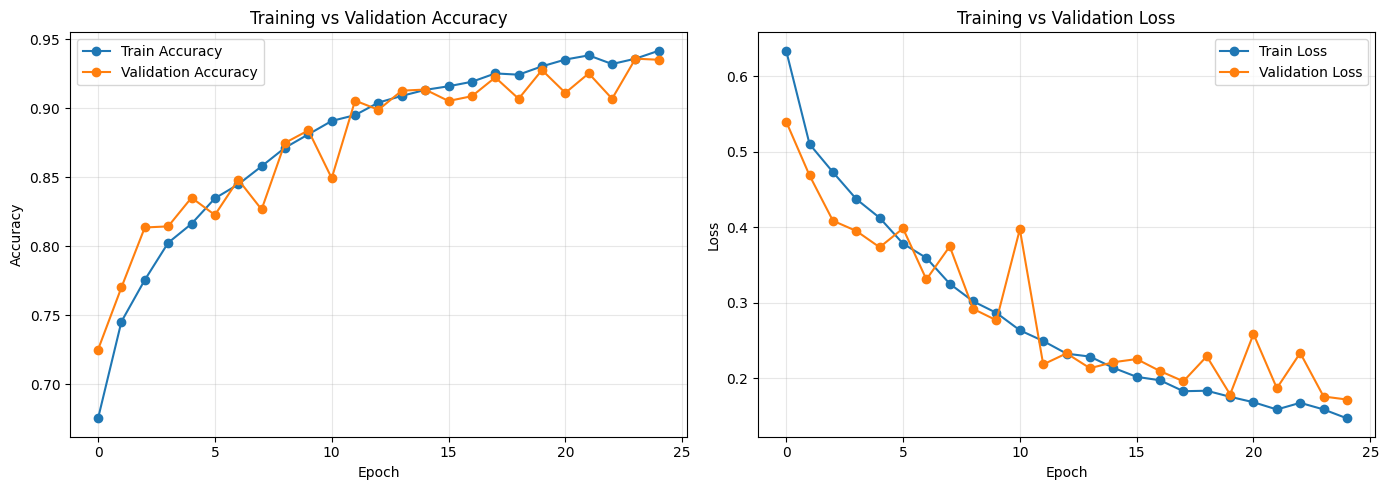

In [67]:

# ===========================================================================
# 13. PLOT TRAINING / VALIDATION ACCURACY AND LOSS
# ===========================================================================

history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history_df["accuracy"], label="Train Accuracy", marker="o")
axes[0].plot(history_df["val_accuracy"], label="Validation Accuracy", marker="o")
axes[0].set_title("Training vs Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss plot
axes[1].plot(history_df["loss"], label="Train Loss", marker="o")
axes[1].plot(history_df["val_loss"], label="Validation Loss", marker="o")
axes[1].set_title("Training vs Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



## 14. Evaluate on the Held-Out Test Set

We reload the **best** checkpointed model (highest validation accuracy) and
evaluate it on the test set, which the model has never seen during training
or validation. We compute:

- **Accuracy** — overall fraction of correct predictions.
- **Precision** — of all images predicted "dog", what fraction truly were?
- **Recall** — of all true "dog" images, what fraction did we correctly find?
- **F1-score** — harmonic mean of precision and recall, useful when classes
  could be imbalanced.
- **Confusion Matrix** — full breakdown of true vs. predicted labels.
- **Classification Report** — per-class precision/recall/F1 in one table.


In [68]:

# ===========================================================================
# 14. EVALUATE THE BEST MODEL ON THE TEST SET
# ===========================================================================

# Load the best-performing checkpoint saved during training
best_model = load_model(CHECKPOINT_PATH)

# Basic Keras evaluation (loss + accuracy)
test_loss, test_accuracy = best_model.evaluate(test_generator, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Generate predictions for detailed metrics
test_generator.reset()
y_pred_probs = best_model.predict(test_generator, verbose=1).ravel()
y_pred = (y_pred_probs >= 0.5).astype(int)
y_true = test_generator.classes  # aligned because shuffle=False

idx_to_class = {v: k for k, v in test_generator.class_indices.items()}

# Core metrics
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\n========== Evaluation Metrics ==========")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\n========== Classification Report ==========")
print(classification_report(
    y_true, y_pred,
    target_names=[idx_to_class[0], idx_to_class[1]]
))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix (rows=true, cols=predicted):")
print(cm)


118/118 ━━━━━━━━━━━━━━━━━━━━ 14s 107ms/step - accuracy: 0.9328 - loss: 0.1655

Test Loss: 0.1655
Test Accuracy: 0.9328
118/118 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step

========== Evaluation Metrics ==========
Accuracy : 0.9328
Precision: 0.9121
Recall   : 0.9579
F1 Score : 0.9344

========== Classification Report ==========
              precision    recall  f1-score   support

         cat       0.96      0.91      0.93      1875
         dog       0.91      0.96      0.93      1875

    accuracy                           0.93      3750
   macro avg       0.93      0.93      0.93      3750
weighted avg       0.93      0.93      0.93      3750


Confusion Matrix (rows=true, cols=predicted):
[[1702  173]
 [  79 1796]]



## 15. Confusion Matrix Heatmap

A visual heatmap makes it immediately clear where the model confuses cats
for dogs (or vice versa), which is harder to read from raw numbers alone.


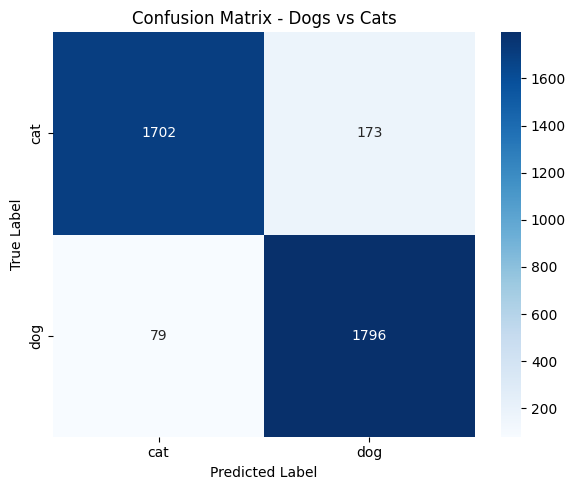

In [69]:

# ===========================================================================
# 15. CONFUSION MATRIX HEATMAP
# ===========================================================================

class_labels = [idx_to_class[0], idx_to_class[1]]

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_labels, yticklabels=class_labels,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Dogs vs Cats")
plt.tight_layout()
plt.show()



## 16. Predict on a Custom Dog/Cat Image

Finally, a reusable utility function that takes the **path to any image**
(uploaded by the user, e.g. via *Add Data → Upload* on Kaggle, or any file
already present in the input/working directories), preprocesses it
identically to training (resize to 224×224, normalize to `[0, 1]`), and
returns the predicted class with a confidence score.

To try it on your own photo:
1. Upload an image to your Kaggle notebook (e.g. into `/kaggle/working/`).
2. Set `custom_image_path` below to that file's path.
3. Run the cell.

Below we first demonstrate the function on a few images sampled from the
test set (so the notebook is runnable end-to-end without any manual
upload), then show how to point it at your own image.


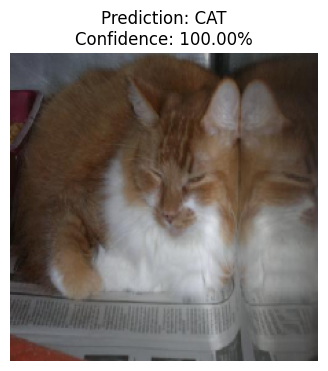

True label: cat | Predicted: cat | Confidence: 100.00%



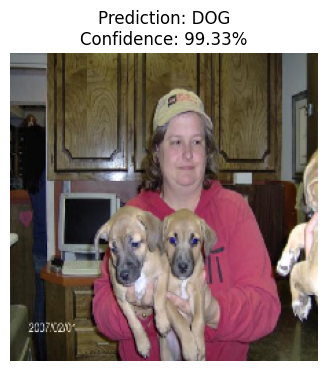

True label: dog | Predicted: dog | Confidence: 99.33%



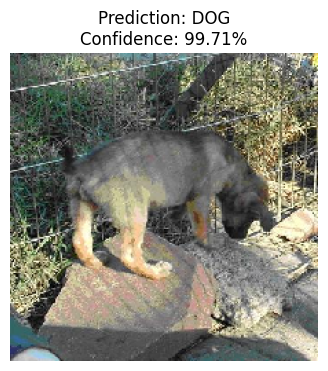

True label: dog | Predicted: dog | Confidence: 99.71%



In [70]:

# ===========================================================================
# 16. CUSTOM IMAGE PREDICTION FUNCTION
# ===========================================================================

def predict_image(model, img_path, class_index_map, img_size=IMG_SIZE):
    """
    Predict whether `img_path` shows a cat or a dog.

    Returns a tuple (predicted_label, confidence) and displays the image
    with the prediction overlaid as the plot title.
    """
    img = load_img(img_path, target_size=img_size)
    img_array = img_to_array(img) / 255.0          # normalize like training
    img_batch = np.expand_dims(img_array, axis=0)  # add batch dimension

    prob = model.predict(img_batch, verbose=0)[0][0]
    predicted_idx = int(prob >= 0.5)
    predicted_label = class_index_map[predicted_idx]
    # Confidence = how strongly the model favors the predicted class
    confidence = prob if predicted_idx == 1 else 1 - prob

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {predicted_label.upper()}\nConfidence: {confidence:.2%}")
    plt.show()

    return predicted_label, confidence


# --- Demo: run predictions on a few held-out test images -------------------
demo_samples = test_df.sample(n=3, random_state=SEED)
for _, row in demo_samples.iterrows():
    label, conf = predict_image(best_model, row["filepath"], idx_to_class)
    print(f"True label: {row['label']} | Predicted: {label} | Confidence: {conf:.2%}\n")

# --- To classify your own image, set the path below and run: --------------
# custom_image_path = "/kaggle/working/my_uploaded_photo.jpg"
# label, conf = predict_image(best_model, custom_image_path, idx_to_class)
# print(f"Predicted: {label} ({conf:.2%} confidence)")



## 17. Summary

In this notebook we:
- Programmatically inspected the raw Kaggle dataset structure with
  `os.walk()` and dynamically located the cat/dog image folders.
- Detected and excluded corrupted/unreadable images before training.
- Built a stratified 70/15/15 train/validation/test split.
- Preprocessed images (resize to 224×224, normalize to `[0, 1]`) and applied
  rotation/zoom/horizontal-flip augmentation to the training set only.
- Built and trained a CNN from scratch (`Conv2D` → `BatchNormalization` →
  `MaxPooling2D` blocks, followed by `Dense`/`Dropout` layers) using Adam,
  binary cross-entropy, `EarlyStopping`, and `ModelCheckpoint`.
- Evaluated the best checkpoint with accuracy, precision, recall, F1-score,
  a confusion matrix, and a full classification report.
- Visualized sample images, training curves, and the confusion matrix.
- Provided a reusable function to classify any new dog/cat photo with a
  confidence score.

### Possible next steps
- Try **transfer learning** (e.g. `MobileNetV2`, `EfficientNetB0`) for
  higher accuracy with less training time.
- Add more augmentation (shear, brightness/contrast jitter) or
  `tf.data`-based pipelines for faster I/O at scale.
- Perform hyperparameter tuning (learning rate, filter counts, dropout
  rate) with `keras_tuner`.
- Add **Grad-CAM** visualizations to interpret which image regions drive
  each prediction.
